# 1.导入所需要的包

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 2.读取数据

In [3]:
data=pd.read_csv(r'C:\Users\wangg\PycharmProjects\基于异质性因果推断的精准营销策略\data\data.csv')
# 探索数据基本信息
# 数据集各列数据类型
print(data.dtypes)
column=list(data.columns)
for i in column:
    print('='*20+i+'='*20)
    print(data[i].describe())
# 探索处理列分布
print('='*20+'处理列分布'+'='*20)
print(data['offer'].value_counts())
# 结果列分布
print('='*20+'结果列分布'+'='*20)
print(data['conversion'].value_counts())

recency            int64
history          float64
used_discount      int64
used_bogo          int64
zip_code          object
is_referral        int64
channel           object
offer             object
conversion         int64
dtype: object
====================recency====================
count    64000.000000
mean         5.763734
std          3.507592
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         12.000000
Name: recency, dtype: float64
====================history====================
count    64000.000000
mean       242.085656
std        256.158608
min         29.990000
25%         64.660000
50%        158.110000
75%        325.657500
max       3345.930000
Name: history, dtype: float64
====================used_discount====================
count    64000.000000
mean         0.551031
std          0.497393
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: used_discount, dt

Buy One Get One,Discount,No Offer三种情况分布均匀，整个数据集未转化人数为54606人，转化人数为9394人，模型训练时建议添加权重，zip_code共有三类，分别为郊外、农村、城市，channel也有三类，分别为Web、Phone、Multichannel，建议转为one-hot编码,recency为最近的一次购买离当前几个月，建议保持为数值列，history为历史总消费，use_discount为是否使用过折扣，use_bogo为是否使用过Buy One Get One营销策略，is_referral表示用户是否来自与推荐渠道，conversion为是否购买，offer为offer类型

# 缺失值观察

In [4]:
for i in column:
    print('='*20+i+'缺失值数量'+'='*20)
    print(data[i].isnull().sum())

====================recency缺失值数量====================
0
====================history缺失值数量====================
0
====================used_discount缺失值数量====================
0
====================used_bogo缺失值数量====================
0
====================zip_code缺失值数量====================
0
====================is_referral缺失值数量====================
0
====================channel缺失值数量====================
0
====================offer缺失值数量====================
0
====================conversion缺失值数量====================
0


数据中不存在缺失值，不需要处理

# 4.异常值观察

0


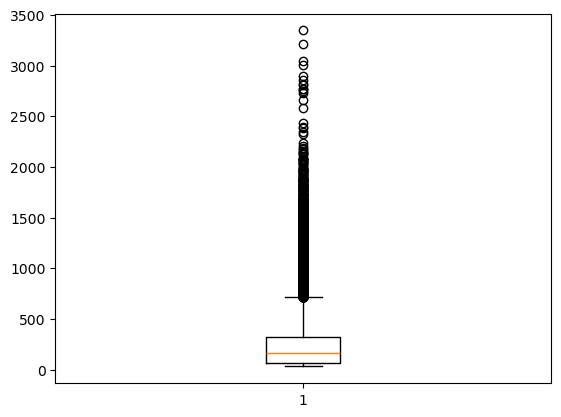

In [5]:
print((data['history']<0).sum())
# 绘制history列箱线图
plt.boxplot(data['history'])
plt.show()

历史总消费金额存为长尾分布，建议取对数值

In [6]:
data['history']=np.log(data['history'])

# 5.数据可视化

## 1.不同处理策略的购买率

             offer  conversion
0  Buy One Get One    0.151400
1         Discount    0.182757
2         No Offer    0.106167


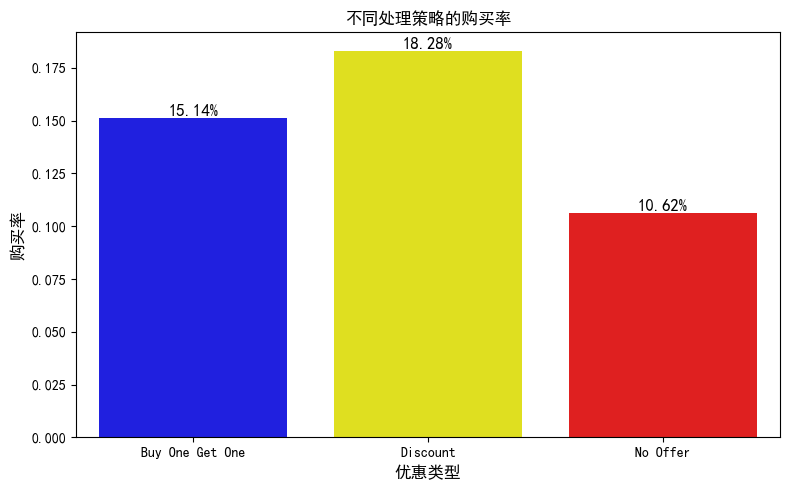

In [7]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
offer_convertion_rate=data.groupby('offer')['conversion'].agg(lambda x:x.sum()/x.count()).reset_index()
print(offer_convertion_rate)
plt.figure(figsize=(8,5))
ax=sns.barplot(x='offer',y='conversion',data=offer_convertion_rate,palette=['blue','yellow','red'],hue='offer',legend=False)
for p in ax.patches:
   height=p.get_height()
   ax.annotate(
       f'{height:.2%}',
       (p.get_x()+p.get_width()/2.,height),
       ha='center',
       va='bottom',
       fontsize=12
   )
plt.title('不同处理策略的购买率')
plt.ylabel('购买率', fontsize=12)
plt.xlabel('优惠类型', fontsize=12)
plt.tight_layout()
plt.show()

营销策略具有明显的效果，discount营销策略转化率最高,转化率为18.28%

## 2.不同渠道下用户购买率对比

In [8]:
channel_offer_distribution=data.groupby(['channel','offer'])['conversion'].agg('count')
channel_offer_distribution

channel       offer          
Multichannel  Buy One Get One    2579
              Discount           2577
              No Offer           2606
Phone         Buy One Get One    9454
              Discount           9240
              No Offer           9327
Web           Buy One Get One    9354
              Discount           9490
              No Offer           9373
Name: conversion, dtype: int64

不同频道的处理与否分布的十分均匀，可以观察不同频道的购买率

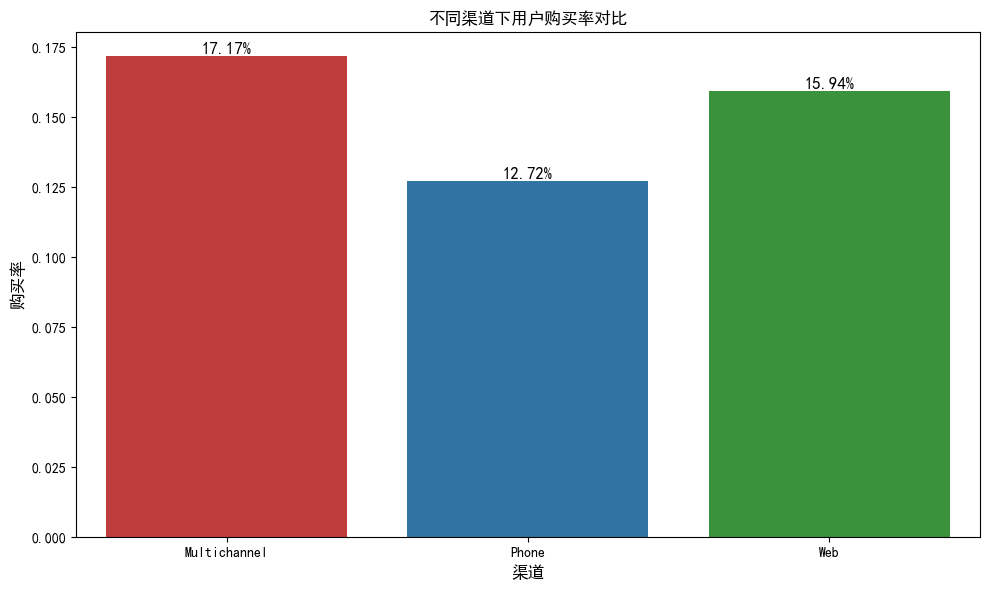

In [9]:
channel_conversion_rate= data.groupby(['channel'])['conversion'].mean().reset_index()
plt.figure(figsize=(10,6))
ax=sns.barplot(x='channel',y='conversion',data=channel_conversion_rate,palette=['#d62728','#1f77b4','#2ca02c'],hue='channel',legend=False)
for p in ax.patches:
    height=p.get_height()
    ax.annotate(
        f'{height:.2%}',
        (p.get_x()+p.get_width()/2.,height),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.xlabel('渠道', fontsize=12)
plt.ylabel('购买率', fontsize=12)
plt.title('不同渠道下用户购买率对比')
plt.tight_layout()
plt.show()

Multichannel渠道各种处理方式购买率最高，Phone渠道购买率最低

## 3.是否为推荐渠道用户与转化率的关系

In [10]:
refer_offer_distribution=data.groupby(['is_referral','offer'])['conversion'].agg('count')
refer_offer_distribution

is_referral  offer          
0            Buy One Get One    10624
             Discount           10621
             No Offer           10611
1            Buy One Get One    10763
             Discount           10686
             No Offer           10695
Name: conversion, dtype: int64

是否为推荐渠道用户中三种处理方式分布均匀，可以观察与转化率的关系

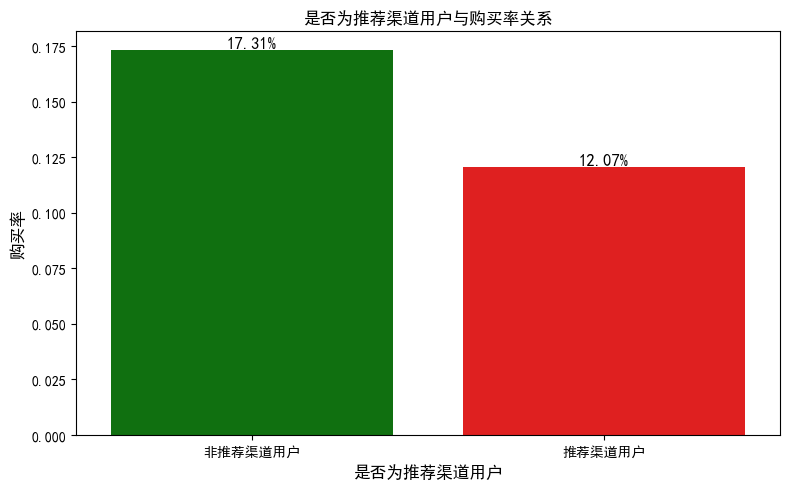

In [11]:
is_refer_conversion_rate=data.groupby(['is_referral'])['conversion'].agg(lambda x:x.sum()/x.count()).reset_index()
is_refer_conversion_rate['is_referral'] = is_refer_conversion_rate['is_referral'].map({
    0: '非推荐渠道用户',
    1: '推荐渠道用户'
})
plt.figure(figsize=(8,5))
ax=sns.barplot(x='is_referral',y='conversion',data=is_refer_conversion_rate,palette=['green','red'],hue='is_referral',legend=False)
for p in ax.patches:
   height=p.get_height()
   ax.annotate(
       f'{height:.2%}',
       (p.get_x()+p.get_width()/2.,height),
       ha='center',
       va='bottom',
       fontsize=12
   )
plt.title('是否为推荐渠道用户与购买率关系')
plt.ylabel('购买率', fontsize=12)
plt.xlabel('是否为推荐渠道用户', fontsize=12)
plt.tight_layout()
plt.show()

非推荐渠道用户转化率高于推荐渠道用户

## 4.不同居住地区与购买率的关系

In [12]:
zip_code_offer_distribution=data.groupby(['zip_code','offer'])['conversion'].agg('count')
zip_code_offer_distribution

zip_code   offer          
Rural      Buy One Get One    3181
           Discount           3243
           No Offer           3139
Surburban  Buy One Get One    9650
           Discount           9501
           No Offer           9625
Urban      Buy One Get One    8556
           Discount           8563
           No Offer           8542
Name: conversion, dtype: int64

分布均匀，可以观察与购买率关系

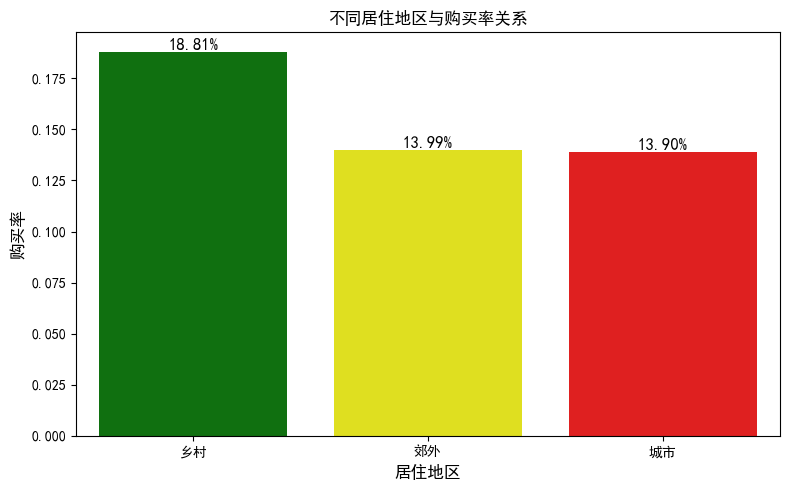

In [13]:
zip_code_conversion_rate=data.groupby(['zip_code'])['conversion'].agg(lambda x:x.sum()/x.count()).reset_index()
zip_code_conversion_rate['zip_code'] = zip_code_conversion_rate['zip_code'].map({
    'Surburban': '郊外',
    'Rural': '乡村',
    'Urban': '城市'
})
plt.figure(figsize=(8,5))
ax=sns.barplot(x='zip_code',y='conversion',data=zip_code_conversion_rate,palette=['green','yellow','red'],hue='zip_code',legend=False)
for p in ax.patches:
   height=p.get_height()
   ax.annotate(
       f'{height:.2%}',
       (p.get_x()+p.get_width()/2.,height),
       ha='center',
       va='bottom',
       fontsize=12
   )
plt.title('不同居住地区与购买率关系')
plt.ylabel('购买率', fontsize=12)
plt.xlabel('居住地区', fontsize=12)
plt.tight_layout()
plt.show()

居住地区为乡村的购买率最高

## 6.各渠道：相比无优惠，折扣/买一送一的购买率提升

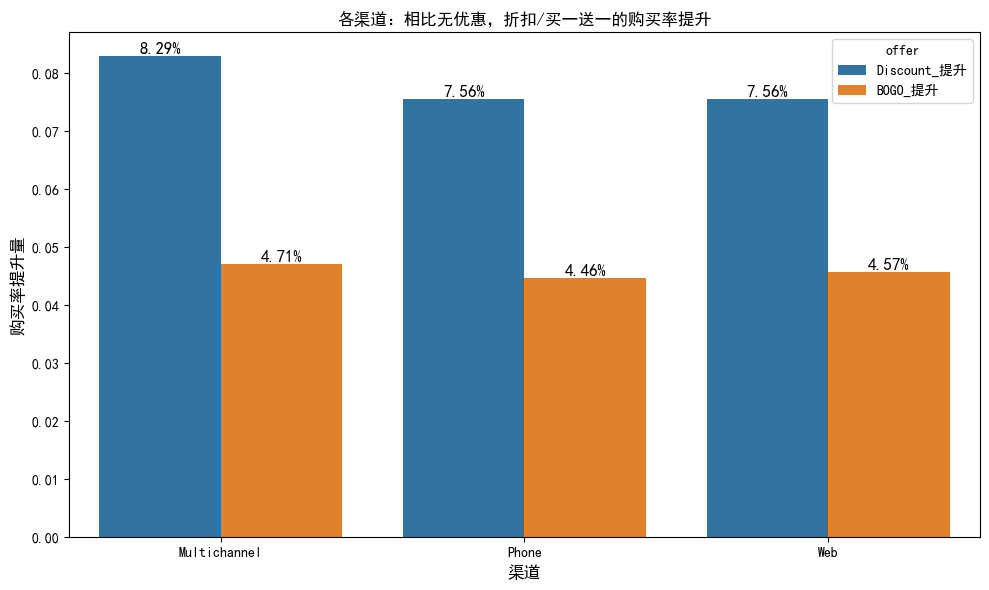

In [14]:
channel_offer_conversion_rate=data.groupby(['channel','offer'])['conversion'].agg(lambda x:x.sum()/x.count()).reset_index()
pivot = channel_offer_conversion_rate.pivot(index='channel', columns='offer', values='conversion')
pivot['Discount_提升'] = pivot['Discount'] - pivot['No Offer']
pivot['BOGO_提升'] = pivot['Buy One Get One'] - pivot['No Offer']
lift_df = pivot[['Discount_提升', 'BOGO_提升']].stack().reset_index()
lift_df.columns = ['channel', 'offer', 'lift_rate']
lift_df
plt.figure(figsize=(10,6))
ax2 = sns.barplot(
    x='channel',
    y='lift_rate',
    hue='offer',
    data=lift_df,
    palette=['#1f77b4','#ff7f0e']
)
for p in ax2.patches:
    height = p.get_height()
    if height > 1e-6:
        ax2.annotate(
            f'{height:.2%}',
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom', fontsize=12
        )
plt.xlabel('渠道', fontsize=12)
plt.ylabel('购买率提升量', fontsize=12)
plt.title('各渠道：相比无优惠，折扣/买一送一的购买率提升')
plt.tight_layout()
plt.show()

多渠道的用户使用营销策略所带来的购买率提升量最高

## 7.各地区：相比无优惠，折扣/买一送一的购买率提升

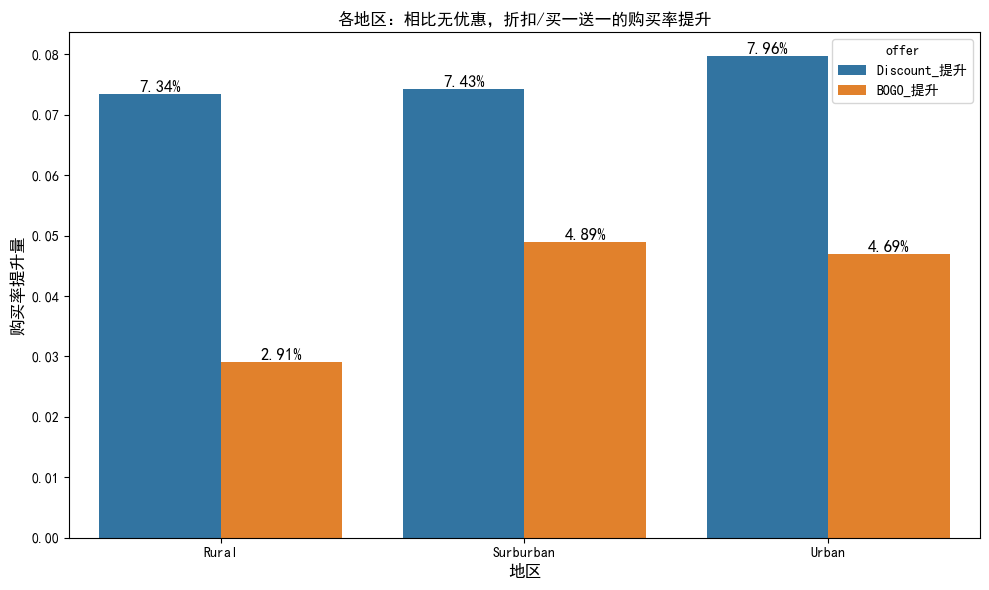

In [15]:
zip_code_offer_conversion_rate=data.groupby(['zip_code','offer'])['conversion'].agg(lambda x:x.sum()/x.count()).reset_index()
pivot = zip_code_offer_conversion_rate.pivot(index='zip_code', columns='offer', values='conversion')
pivot['Discount_提升']=pivot['Discount']-pivot['No Offer']
pivot['BOGO_提升']=pivot['Buy One Get One']-pivot['No Offer']
lift_df1=pivot[['Discount_提升', 'BOGO_提升']].stack().reset_index()
lift_df1.columns = ['zip_code', 'offer', 'lift_rate']
plt.figure(figsize=(10,6))
ax3 = sns.barplot(
    x='zip_code',
    y='lift_rate',
    hue='offer',
    data=lift_df1,
    palette=['#1f77b4','#ff7f0e']
)
for p in ax3.patches:
    height = p.get_height()
    if height > 1e-6:
        ax3.annotate(
            f'{height:.2%}',
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom', fontsize=12
        )
plt.xlabel('地区', fontsize=12)
plt.ylabel('购买率提升量', fontsize=12)
plt.title('各地区：相比无优惠，折扣/买一送一的购买率提升')
plt.tight_layout()
plt.show()

城市地区对于折扣更加敏感，购买率提升量最多，郊区对于买一送一策略最敏感，购买率提升量最多

## 8.最近一次购买距离目前的月份与购买率的关系

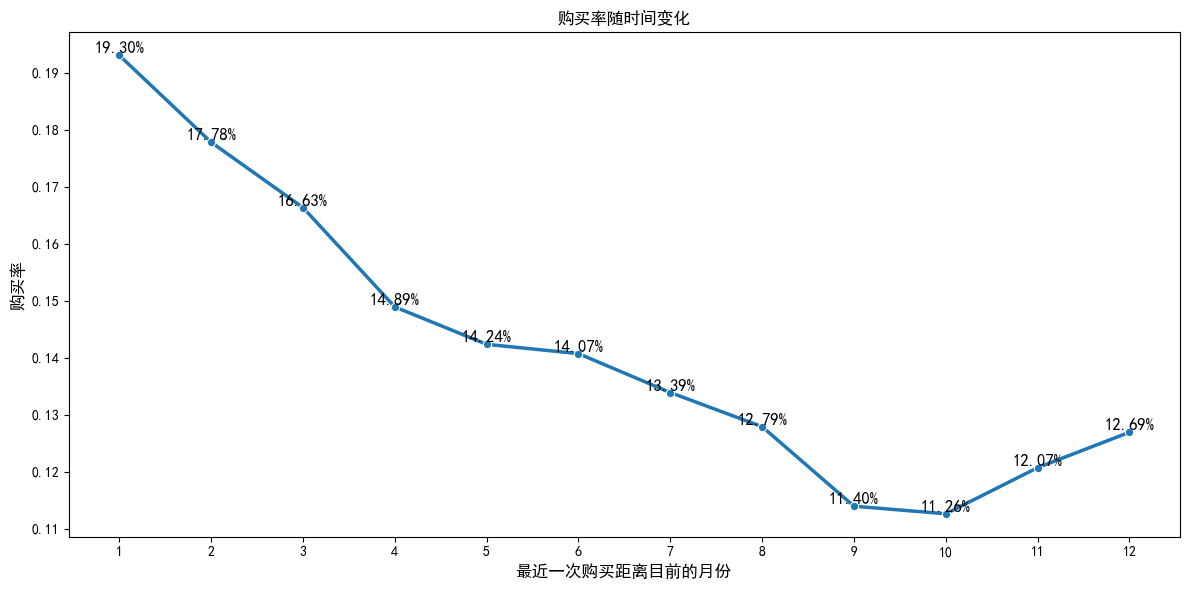

In [16]:
recency_conversion_rate=data.groupby(['recency'])['conversion'].agg('mean').reset_index()
plt.figure(figsize=(12,6))
ax4=sns.lineplot(x='recency',y='conversion',data=recency_conversion_rate,marker='o', linewidth=2.5)
for line in ax4.lines:
    x=line.get_xdata()
    y=line.get_ydata()
    for xi,yi in zip(x,y):
        ax4.annotate(
            f'{yi:.2%}',
            xy=(xi,yi),
            ha='center',
            va='bottom',
            fontsize=12
        )
full_x_ticks = recency_conversion_rate['recency'].tolist()
ax4.set_xticks(full_x_ticks)
plt.title('购买率随时间变化')
plt.ylabel('购买率', fontsize=12)
plt.xlabel('最近一次购买距离目前的月份', fontsize=12)
plt.tight_layout()
plt.show()

随着最近一次购买距今月份越大，折扣 / 买一送一活动的转化购买率持续下降，而整整 10 个月以上没有复购、但依然没有卸载平台，一旦买一送一、大额折扣强促销触达，这批用户的需求会被瞬间唤醒，转化意愿远高于中途流失的普通用户，因此转化率逆势抬升。

## 9.历史购买总金额与购买转化的关系

In [17]:
data1=data.copy()
data1['history_bins']=pd.qcut(data1['history'],q=10,duplicates='drop')
data1['is_treated']=data1['offer'].apply(lambda x:0 if x=='No Offer' else 1)
amount_treated_count=data1.groupby('history_bins', observed=False).agg(总人数=('is_treated', 'count'),
    处理人数=('is_treated', 'sum'),
    未处理人数=('is_treated', lambda x: (x==0).sum()),
    处理率=('is_treated', 'mean')).reset_index()
amount_treated_count

,history_bins,总人数,处理人数,未处理人数,处理率
0,"(3.4, 3.918]",12800,8533,4267,0.666641
1,"(3.918, 4.384]",6400,4318,2082,0.674687
2,"(4.384, 4.747]",6401,4256,2145,0.664896
3,"(4.747, 5.063]",6400,4179,2221,0.652969
4,"(5.063, 5.351]",6400,4294,2106,0.670937
5,"(5.351, 5.639]",6400,4294,2106,0.670937
6,"(5.639, 5.946]",6399,4252,2147,0.664479
7,"(5.946, 6.33]",6400,4296,2104,0.671250
8,"(6.33, 8.115]",6400,4272,2128,0.667500


各个金额分桶中处理概率非常相似，可以进行可视化分析

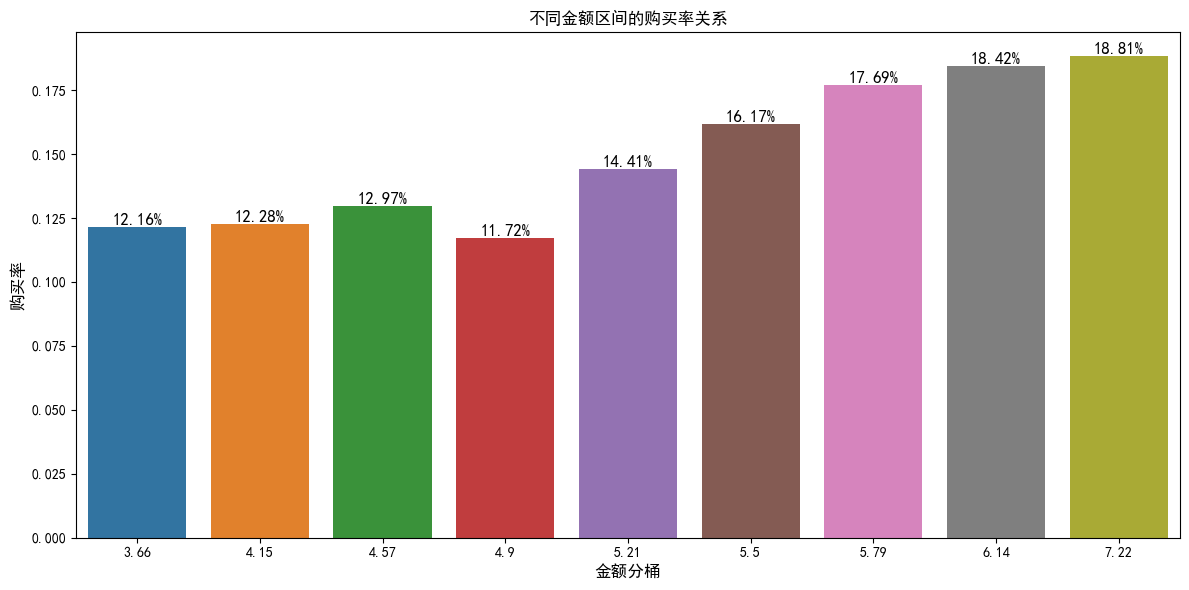

In [18]:
amount_conversion_rate=data1.groupby('history_bins',observed=False).agg({'conversion':'mean'}).reset_index()
amount_conversion_rate['history_bins'] = amount_conversion_rate['history_bins'].apply(lambda x: round((x.left + x.right)/2, 2))
plt.figure(figsize=(12,6))
ax5=sns.barplot(x='history_bins',y='conversion',data=amount_conversion_rate,hue='history_bins',legend=False)
for p in ax5.patches:
    height=p.get_height()
    ax5.annotate(
        f'{height:.2%}',
        (p.get_x()+p.get_width()/2.,height),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title('不同金额区间的购买率关系')
plt.ylabel('购买率', fontsize=12)
plt.xlabel('金额分桶', fontsize=12)
plt.tight_layout()
plt.show()

历史购买总金额与购买转换存在正相关

In [8]:
# 导出数据
data_processed=data.to_csv(r'C:\Users\wangg\PycharmProjects\基于异质性因果推断的精准营销策略\data\data_processed.csv',index=False)